In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

from ucimlrepo import fetch_ucirepo

In [2]:
!pip install ucimlrepo

In [13]:
air_quality = fetch_ucirepo(id=360)

df = air_quality.data.features

In [14]:
features = df[['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']]

features.head()

,CO(GT),C6H6(GT),NOx(GT),NO2(GT)
0,2.6,11.9,166,113
1,2.0,9.4,103,92
2,2.2,9.0,131,114
3,2.2,9.2,172,122
4,1.6,6.5,131,116


In [16]:
features.isnull().sum()

CO(GT)      0
C6H6(GT)    0
NOx(GT)     0
NO2(GT)     0
dtype: int64

In [17]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CO(GT)    9357 non-null   float64
 1   C6H6(GT)  9357 non-null   float64
 2   NOx(GT)   9357 non-null   int64  
 3   NO2(GT)   9357 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 292.5 KB


In [22]:
#parameters for isolation forest
n_estimators = 100 #no of trees in the forest
contamination = 0.01 #proportion of outliers in the data set
sample_size = 256

In [23]:
model = IsolationForest(n_estimators=n_estimators, contamination=contamination,
                         max_samples=sample_size, random_state=42)   

model.fit(features)

# predict anomalies
anomaly_labels = model.predict(features)

# -1 for anomalies and 1 for normal data points
print("Anomaly labels:", anomaly_labels)

Anomaly labels: [1 1 1 ... 1 1 1]


In [24]:
features['anomaly'] = anomaly_labels
features.head()

C:\Users\deeks\AppData\Local\Temp\ipykernel_17692\2357824566.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['anomaly'] = anomaly_labels


,CO(GT),C6H6(GT),NOx(GT),NO2(GT),anomaly
0,2.6,11.9,166,113,1
1,2.0,9.4,103,92,1
2,2.2,9.0,131,114,1
3,2.2,9.2,172,122,1
4,1.6,6.5,131,116,1


In [25]:
features['anomaly'].value_counts()

anomaly
 1    9263
-1      94
Name: count, dtype: int64

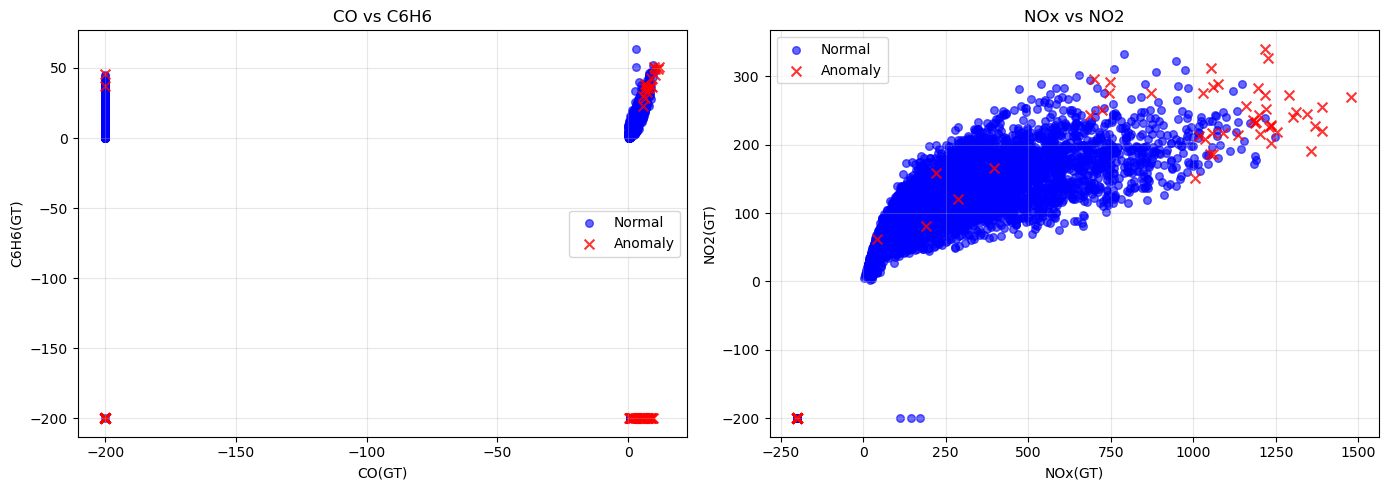

Anomalies detected: 94
Normal data points: 9263


In [ ]:
# Visualize anomalies - Multiple feature comparisons
fig, axes = plt.subplots(1, 2, figsize=(14,5))

normal = features[features['anomaly' ] == 1]
anomaly = features[features['anomaly'] == -1]

# Plot 1: CO vs C6H6
axes[0].scatter(normal['CO(GT)'], normal['C6H6(GT)'], color='blue', label='Normal', alpha=0.6, s=30)
axes[0].scatter(anomaly['CO(GT)'], anomaly['C6H6(GT)'], color='red', label='Anomaly', alpha=0.8, s=50, marker='x' )
axes[0].set_xlabel('CO(GT)')
axes[0].set_ylabel('C6H6(GT)')
axes[0].set_title('CO vs C6H6')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: NOx vs NO2
axes[1].scatter(normal['NOx(GT)'], normal['NO2(GT)'], color='blue', label='Normal', alpha=0.6, s=30)
axes[1].scatter(anomaly['NOx(GT)'], anomaly['NO2(GT)'], color='red', label='Anomaly', alpha=0.8, s=50, marker='x' )
axes[1].set_xlabel('NOx(GT)')
axes[1].set_ylabel('NO2(GT)')
axes[1].set_title('NOx vs NO2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Anomalies detected:", len(anomaly))
print("Normal data points:", len(normal))

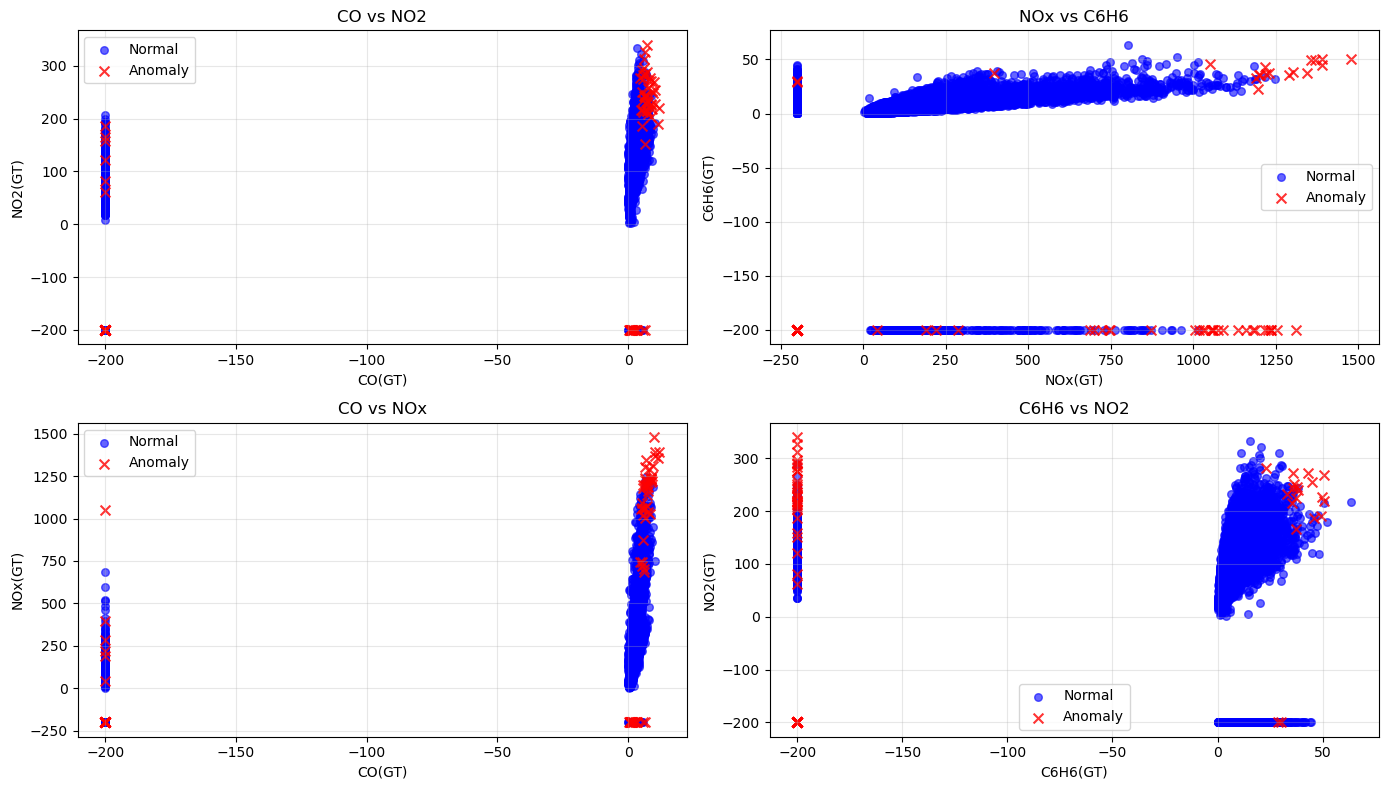

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14,8))

normal = features[features['anomaly'] == 1]
anomaly = features[features['anomaly'] == -1]

# Plot 1: CO vs NO2
axes[0][0].scatter(normal['CO(GT)'], normal['NO2(GT)'],
                   color='blue', label='Normal', alpha=0.6, s=30)
axes[0][0].scatter(anomaly['CO(GT)'], anomaly['NO2(GT)'],
                   color='red', label='Anomaly', alpha=0.8, s=50, marker='x')
axes[0][0].set_title('CO vs NO2')
axes[0][0].set_xlabel('CO(GT)')
axes[0][0].set_ylabel('NO2(GT)')
axes[0][0].legend()
axes[0][0].grid(True, alpha=0.3)


# Plot 2: NOx vs C6H6
axes[0][1].scatter(normal['NOx(GT)'], normal['C6H6(GT)'],
                   color='blue', label='Normal', alpha=0.6, s=30)
axes[0][1].scatter(anomaly['NOx(GT)'], anomaly['C6H6(GT)'],
                   color='red', label='Anomaly', alpha=0.8, s=50, marker='x')
axes[0][1].set_title('NOx vs C6H6')
axes[0][1].set_xlabel('NOx(GT)')
axes[0][1].set_ylabel('C6H6(GT)')
axes[0][1].legend()
axes[0][1].grid(True, alpha=0.3)


# Plot 3: CO vs NOx
axes[1][0].scatter(normal['CO(GT)'], normal['NOx(GT)'],
                   color='blue', label='Normal', alpha=0.6, s=30)
axes[1][0].scatter(anomaly['CO(GT)'], anomaly['NOx(GT)'],
                   color='red', label='Anomaly', alpha=0.8, s=50, marker='x')
axes[1][0].set_title('CO vs NOx')
axes[1][0].set_xlabel('CO(GT)')
axes[1][0].set_ylabel('NOx(GT)')
axes[1][0].legend()
axes[1][0].grid(True, alpha=0.3)


# Plot 4: C6H6 vs NO2
axes[1][1].scatter(normal['C6H6(GT)'], normal['NO2(GT)'],
                   color='blue', label='Normal', alpha=0.6, s=30)
axes[1][1].scatter(anomaly['C6H6(GT)'], anomaly['NO2(GT)'],
                   color='red', label='Anomaly', alpha=0.8, s=50, marker='x')
axes[1][1].set_title('C6H6 vs NO2')
axes[1][1].set_xlabel('C6H6(GT)')
axes[1][1].set_ylabel('NO2(GT)')
axes[1][1].legend()
axes[1][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
import plotly.graph_objects as go
import numpy as np
 
# Separate normal and anomaly
normal = features[features['anomaly'] == 1]
anomaly = features[features['anomaly'] == -1]
 
fig = go.Figure()
 
# Normal points
fig.add_trace(go.Scatter3d(
    x=normal['CO(GT)'],
    y=normal['C6H6(GT)'],
    z=normal['NOx(GT)'],
    mode='markers',
    name='Normal',
    marker=dict(
        size=6,
        color=normal['NO2(GT)'],   # 4th dimension as color
        colorscale='Blues',
        opacity=0.6,
        colorbar=dict(title='NO2(GT)')
    )
))
 
# Anomaly points
fig.add_trace(go.Scatter3d(
    x=anomaly['CO(GT)'],
    y=anomaly['C6H6(GT)'],
    z=anomaly['NOx(GT)'],
    mode='markers',
    name='Anomaly',
    marker=dict(
        size=8,
        color=anomaly['NO2(GT)'],
        colorscale='Reds',
        opacity=0.9,
        symbol='diamond'
    )
))
 
# Layout
fig.update_layout(
    title='4D Scatter Plot (Color = NO2(GT))',
    scene=dict(
        xaxis_title='CO(GT)',
        yaxis_title='C6H6(GT)',
        zaxis_title='NOx(GT)'
    ),
    width=900,
    height=700
)
 
fig.show()